pandas central récupérer des données et les utiliser dans vos modèles
notamment pour les données "temporelles" => données qui sont datés 

date           prix
01/01/2026 => 100 000
02/01/2026 => 120 000
03/01/2026 => 110 000


# cours de bourse du bitcoin

- <https://www.coingecko.com/en/coins/bitcoin/historical_data?start=2010-06-13&end=2026-06-13>

# cours de bourse de etherium

- <https://www.coingecko.com/en/coins/ethereum/historical_data?start=2015-08-07&end=2026-06-13>

In [4]:
import pandas as pd

bitcoin = pd.read_csv("btc-usd-max.csv" , index_col="snapped_at" , parse_dates=True)

bitcoin.head(3)

,price,market_cap,total_volume
snapped_at,,,
2013-04-28 00:00:00+00:00,135.30,1.500518e+09,0.0
2013-04-29 00:00:00+00:00,141.96,1.575032e+09,0.0
2013-04-30 00:00:00+00:00,135.30,1.501657e+09,0.0


<Axes: xlabel='snapped_at'>

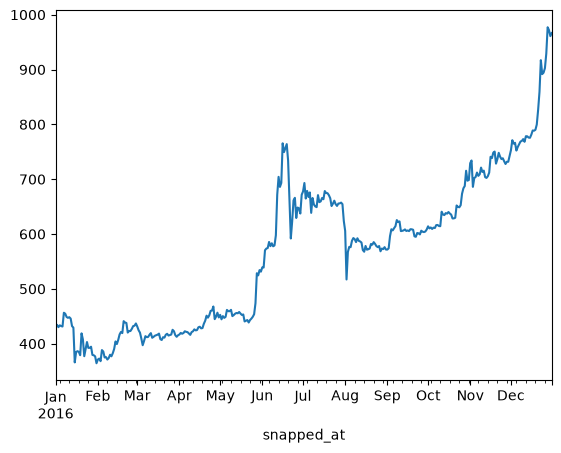

In [8]:
# bitcoin["price"].plot()

bitcoin.loc[ "2016"  , "price" ].plot() # slicing comme sur numpy

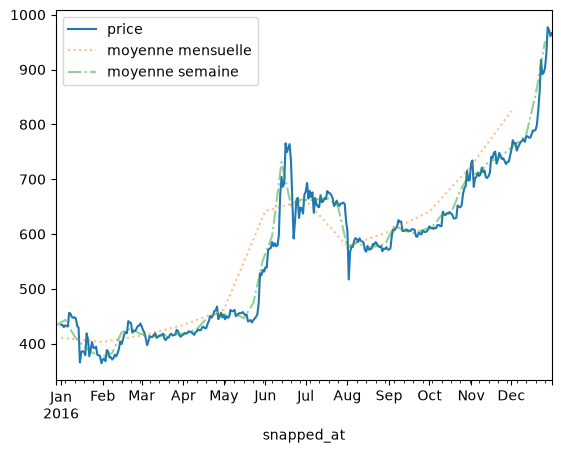

In [16]:
# avoir des indicateurs sur des données temporelles 
# resample() => regrouper les données sur une période

# je veux avoir le prix moyen du bitcoin par mois
import matplotlib.pyplot as plt

bitcoin.loc[ "2016"  , "price" ].resample("ME").mean()
bitcoin.loc[ "2016"  , "price" ].plot()
bitcoin.loc[ "2016"  , "price" ].resample("ME").mean().plot( alpha=0.5 , ls=":", label="moyenne mensuelle")
bitcoin.loc[ "2016"  , "price" ].resample("W").mean().plot( alpha=0.5 , ls="-.", label="moyenne semaine")
plt.legend()

# resample() + agg()
sur une période regroupé temporellement avoir plusieurs indicateurs

In [17]:
bitcoin.loc[ "2016"  , "price" ].resample("ME").agg(["mean", "min" , "max" , "std"])

,mean,min,max,std
snapped_at,,,,
2016-01-31 00:00:00+00:00,410.816171,364.352000,456.434000,29.434064
2016-02-29 00:00:00+00:00,403.203897,368.124000,441.120000,25.484347
2016-03-31 00:00:00+00:00,414.869839,397.241000,431.371000,6.419787
2016-04-30 00:00:00+00:00,434.204867,416.145000,467.856000,15.570636
2016-05-31 00:00:00+00:00,461.975226,438.675000,534.224000,27.495541
2016-06-30 00:00:00+00:00,642.125542,538.832000,765.463000,68.108952
2016-07-31 00:00:00+00:00,661.853865,623.745771,693.047000,13.417073
2016-08-31 00:00:00+00:00,577.688033,517.134929,605.747000,14.204655
2016-09-30 00:00:00+00:00,604.714605,571.590000,625.467500,11.187839


utiliser ces indicateurs dans un graph

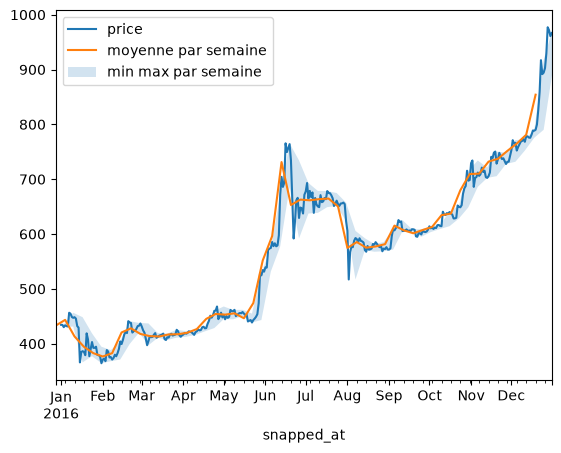

In [19]:
m = bitcoin.loc["2016", "price"].resample("W").agg(["mean","min", "max"])

plt.figure()

bitcoin.loc[ "2016"  , "price" ].plot()
m["mean"]["2016"].plot(label="moyenne par semaine")
plt.fill_between(
            m.index, # date de la période année 2016
            m["max"],  
            m["min"], 
            alpha=0.2 , 
            label="min max par semaine")

plt.legend()


exo : pouvez créer un graphique qui affiche sur la même figure
- le cours moyen du bitcoin mensuel x
- le cours moyen du bitcoin à la semaine
- le min et max de la devise mensuel

sur la période 2026 (réponse dans le tchat de teams)

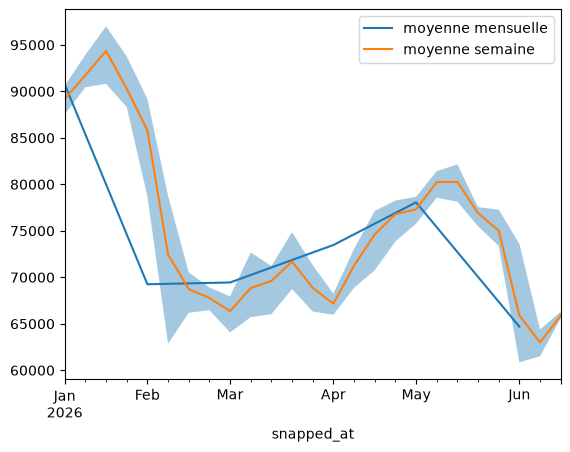

In [29]:
m = bitcoin.loc["2026", "price"].resample("W").agg(["min", "max"])

plt.figure()
bitcoin.loc["2026", "price"].resample("ME").mean().plot( label="moyenne mensuelle")
bitcoin.loc["2026", "price"].resample("W").mean().plot( label="moyenne semaine")
plt.fill_between( 
    m.index,
    m["max"],
    m["min"],
    alpha=0.4
)

plt.legend()

autre type de moyenne que l'on peut utiliser => moyenne mobile
prendre une période => les 7 derniers jours (window) et faire la moyenne sur cette période
puis décaler d'un jour et relancer le calcul de moyenne

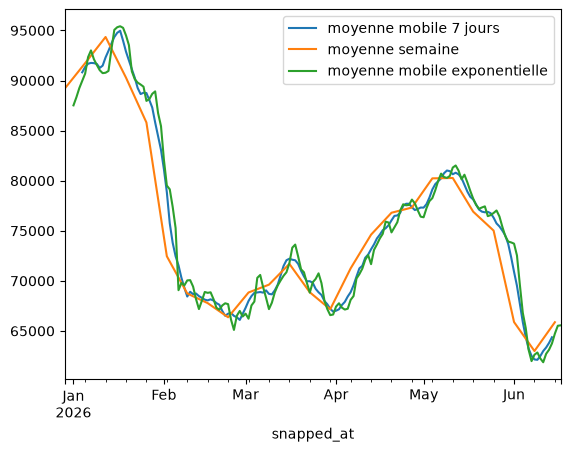

In [ ]:
bitcoin.loc["2026", "price"].rolling( window=7, center=True ).mean().plot( label="moyenne mobile 7 jours")
bitcoin.loc["2026", "price"].resample("W").mean().plot( label="moyenne semaine")
plt.legend()
bitcoin.loc["2026", "price"].ewm( alpha=0.5 ) .mean().plot( label="moyenne mobile exponentielle")
plt.legend()
# moyenne mobile exponentielle => permet à la moyenne d'être sensible aux évolutions avec beaucoup de volatilité
# attention ici alpha c'est le facteur de lissage de la courbe